**Loading and Preparing the Datasets**

In [98]:
# Import required library
import pandas as pd

# Load datasets
wine = pd.read_csv("/content/wine.csv")
chickwts = pd.read_csv("/content/chickwts.csv")
USArrests = pd.read_csv("/content/USArrests.csv")

# Display first few rows of each dataset
print("Wine Dataset:")
display(wine.head())

print("Chickwts Dataset:")
display(chickwts.head())

print("USArrests Dataset:")
display(USArrests.head())

Wine Dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


Chickwts Dataset:


,weight,feed
0,179,horsebean
1,160,horsebean
2,136,horsebean
3,227,horsebean
4,217,horsebean


USArrests Dataset:


,rownames,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


In [99]:
# Display dataset dimensions
print("Wine shape:", wine.shape)
print("Chickwts shape:", chickwts.shape)
print("USArrests shape:", USArrests.shape)


Wine shape: (178, 14)
Chickwts shape: (71, 2)
USArrests shape: (50, 5)


In [100]:
# Display column names
print("Wine columns:")
print(wine.columns)

print("Chickwts columns:")
print(chickwts.columns)

print("USArrests columns:")
print(USArrests.columns)

Wine columns:
Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='object')
Chickwts columns:
Index(['weight', 'feed'], dtype='object')
USArrests columns:
Index(['rownames', 'Murder', 'Assault', 'UrbanPop', 'Rape'], dtype='object')


In [101]:
# Check basic information about datasets
print("Wine Dataset Information:")
wine.info()

print("Chickwts Dataset Information:")
chickwts.info()

print("USArrests Dataset Information:")
USArrests.info()

Wine Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-

In [102]:
# Check missing values

print("Missing values in Wine dataset:")
print(wine.isnull().sum())

print("Missing values in Chickwts dataset:")
print(chickwts.isnull().sum())

print("Missing values in USArrests dataset:")
print(USArrests.isnull().sum())

Missing values in Wine dataset:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64
Missing values in Chickwts dataset:
weight    0
feed      0
dtype: int64
Missing values in USArrests dataset:
rownames    0
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64


In [103]:
# Check duplicate rows

print("Duplicate rows in Wine dataset:", wine.duplicated().sum())
print("Duplicate rows in Chickwts dataset:", chickwts.duplicated().sum())
print("Duplicate rows in USArrests dataset:", USArrests.duplicated().sum())


Duplicate rows in Wine dataset: 0
Duplicate rows in Chickwts dataset: 1
Duplicate rows in USArrests dataset: 0


In [104]:
chickwts = chickwts.drop_duplicates()
print("Duplicate rows in Chickwts dataset:", chickwts.duplicated().sum())

Duplicate rows in Chickwts dataset: 0


In [105]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Select numerical columns and standardize them

# Wine dataset
wine_numeric = wine.select_dtypes(include=['int64', 'float64'])
wine_scaled = pd.DataFrame(
    scaler.fit_transform(wine_numeric),
    columns=wine_numeric.columns
)

# Chickwts dataset
chickwts_numeric = chickwts.select_dtypes(include=['int64', 'float64'])
chickwts_scaled = pd.DataFrame(
    scaler.fit_transform(chickwts_numeric),
    columns=chickwts_numeric.columns
)

# USArrests dataset
USArrests_numeric = USArrests.select_dtypes(include=['int64', 'float64'])
USArrests_scaled = pd.DataFrame(
    scaler.fit_transform(USArrests_numeric),
    columns=USArrests_numeric.columns
)

# Display standardized datasets
print("Wine standardized data:")
display(wine_scaled.head())

print("Chickwts standardized data:")
display(chickwts_scaled.head())

print("USArrests standardized data:")
display(USArrests_scaled.head())

Wine standardized data:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009,-1.213944
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242,-1.213944
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148,-1.213944
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574,-1.213944
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874,-1.213944


Chickwts standardized data:


,weight
0,-1.056916
1,-1.300327
2,-1.607794
3,-0.441983
4,-0.570094


USArrests standardized data:


,Murder,Assault,UrbanPop,Rape
0,1.255179,0.790787,-0.526195,-0.003451
1,0.513019,1.118060,-1.224067,2.509424
2,0.072361,1.493817,1.009122,1.053466
3,0.234708,0.233212,-1.084492,-0.186794
4,0.281093,1.275635,1.776781,2.088814


In [106]:
# Summarize dataset structures

datasets = {
    "Wine": wine,
    "Chickwts": chickwts,
    "USArrests": USArrests
}

for name, data in datasets.items():
    print(f"{name} Dataset Summary")
    print("-" * 40)


    # Dataset dimensions
    print("Shape:", data.shape)

    # Column information
    print("Columns:")
    print(list(data.columns))

    # Data types
    print("Data Types:")
    print(data.dtypes)

    # Statistical summary
    print("Statistical Summary:")
    display(data.describe())

Wine Dataset Summary
----------------------------------------
Shape: (178, 14)
Columns:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'target']
Data Types:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object
Statistical Summary:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


Chickwts Dataset Summary
----------------------------------------
Shape: (70, 2)
Columns:
['weight', 'feed']
Data Types:
weight     int64
feed      object
dtype: object
Statistical Summary:


,weight
count,70.000000
mean,261.500000
std,78.620857
min,108.000000
25%,203.750000
50%,259.000000
75%,324.250000
max,423.000000


USArrests Dataset Summary
----------------------------------------
Shape: (50, 5)
Columns:
['rownames', 'Murder', 'Assault', 'UrbanPop', 'Rape']
Data Types:
rownames     object
Murder      float64
Assault       int64
UrbanPop      int64
Rape        float64
dtype: object
Statistical Summary:


,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


In [107]:
# Check standardized datasets summary

scaled_datasets = {
    "Wine Scaled": wine_scaled,
    "Chickwts Scaled": chickwts_scaled,
    "USArrests Scaled": USArrests_scaled
}

for name, data in scaled_datasets.items():
    print(f"{name} Summary")
    print("-" * 40)
    display(data.describe())

Wine Scaled Summary
----------------------------------------


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,178.000000,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02
mean,-8.382808e-16,-1.197544e-16,-8.370333e-16,-3.991813e-17,-3.991813e-17,0.000000,-3.991813e-16,3.592632e-16,-1.197544e-16,2.494883e-17,1.995907e-16,3.193450e-16,-1.596725e-16,1.596725e-16
std,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00
min,-2.434235e+00,-1.432983e+00,-3.679162e+00,-2.671018e+00,-2.088255e+00,-2.107246,-1.695971e+00,-1.868234e+00,-2.069034e+00,-1.634288e+00,-2.094732e+00,-1.895054e+00,-1.493188e+00,-1.213944e+00
25%,-7.882448e-01,-6.587486e-01,-5.721225e-01,-6.891372e-01,-8.244151e-01,-0.885468,-8.275393e-01,-7.401412e-01,-5.972835e-01,-7.951025e-01,-7.675624e-01,-9.522483e-01,-7.846378e-01,-1.213944e+00
50%,6.099988e-02,-4.231120e-01,-2.382132e-02,1.518295e-03,-1.222817e-01,0.095960,1.061497e-01,-1.760948e-01,-6.289785e-02,-1.592246e-01,3.312687e-02,2.377348e-01,-2.337204e-01,7.996036e-02
75%,8.361286e-01,6.697929e-01,6.981085e-01,6.020883e-01,5.096384e-01,0.808997,8.490851e-01,6.095413e-01,6.291754e-01,4.939560e-01,7.131644e-01,7.885875e-01,7.582494e-01,1.373864e+00
max,2.259772e+00,3.109192e+00,3.156325e+00,3.154511e+00,4.371372e+00,2.539515,3.062832e+00,2.402403e+00,3.485073e+00,3.435432e+00,3.301694e+00,1.960915e+00,2.971473e+00,1.373864e+00


Chickwts Scaled Summary
----------------------------------------


,weight
count,7.000000e+01
mean,-1.427430e-17
std,1.007220e+00
min,-1.966505e+00
25%,-7.398415e-01
50%,-3.202777e-02
75%,8.038970e-01
max,2.068994e+00


USArrests Scaled Summary
----------------------------------------


,Murder,Assault,UrbanPop,Rape
count,5.000000e+01,5.000000e+01,5.000000e+01,5.000000e+01
mean,-7.105427e-17,1.387779e-16,-4.396483e-16,8.593126e-16
std,1.010153e+00,1.010153e+00,1.010153e+00,1.010153e+00
min,-1.620693e+00,-1.524362e+00,-2.340661e+00,-1.502548e+00
25%,-8.611383e-01,-7.486054e-01,-7.704502e-01,-6.640245e-01
50%,-1.247758e-01,-1.425453e-01,3.210209e-02,-1.220847e-01
75%,8.029251e-01,9.483628e-01,8.521012e-01,5.330962e-01
max,2.229265e+00,2.015028e+00,1.776781e+00,2.671197e+00


**Using PCA and hyperparameter tuning to optimize k-NN classification.**

**Convert** **categorical target labels into numeric value**.

Since k-NN is a classification algorithm, the target labels need to be numerical. We will use LabelEncoder.
Before writing the code, we need to decide which dataset is being used for k-NN classification.
From the datasets:
- Wine  = classification dataset (has categorical wine classes)
- Chickwts  = regression/ANOVA-type dataset
- USArrests  = clustering dataset

So we will use the** Wine dataset**



In [108]:
# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder

# Check the columns in the Wine dataset
wine.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='object')

In [109]:
# After checking the columns, encode the target
# Create label encoder
label_encoder = LabelEncoder()

# Convert target labels into numerical values
wine['target_encoded'] = label_encoder.fit_transform(wine['target'])

# Display the mapping of original labels to numbers
print("Class mapping:")
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# Display first few rows
wine.head()


Class mapping:
{np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_encoded
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,0


In [110]:
# Check target data type and unique values

print("Target data type:")
print(wine['target'].dtype)

print("Unique target values:")
print(wine['target'].unique())

Target data type:
int64
Unique target values:
[0 1 2]


**Apply PCA to reduce dimensionality while retaining 95% variance.**

In [111]:
# Import required libraries
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Define features (X) and target (y) for PCA from the wine dataset
X = wine_scaled.copy()
y = wine['target_encoded']

# Apply PCA while retaining 95% variance
pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X)

# Display results
print("Original number of features:", X.shape[1])
print("Number of PCA components retained:", X_pca.shape[1])


Original number of features: 14
Number of PCA components retained: 10


In [112]:
# Explained variance ratio
print("\nExplained variance by each component:")
print(pca.explained_variance_ratio_)

# Total variance retained
print("\nTotal variance retained:")
print(sum(pca.explained_variance_ratio_))


Explained variance by each component:
[0.39542486 0.17836259 0.10329102 0.06627984 0.06267875 0.0480556
 0.03955707 0.02500244 0.02103871 0.01873615]

Total variance retained:
0.958427025994762


**Use GridSearchCV to find the optimal k-value and distance metric.**
For k-NN, we need to tune:
- n_neighbors → the value of k (number of neighbors)
- metric → distance calculation method (e.g., Euclidean, Manhattan)

In [113]:
# Hyperparameter tuning with GridSearchCV
# Import required libraries
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Create k-NN classifier
knn = KNeighborsClassifier()

# Define parameters to test
param_grid = {
    'n_neighbors': range(1, 21),
    'metric': ['euclidean', 'manhattan']
}

# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

# Fit the model using PCA data
grid_search.fit(X_pca, y)



GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': range(1, 21)},
             scoring='accuracy')

In [114]:
# Display best parameters
print("Best parameters:")
print(grid_search.best_params_)

# Display best accuracy
print("Best cross-validation accuracy:")
print(grid_search.best_score_)

Best parameters:
{'metric': 'euclidean', 'n_neighbors': 10}
Best cross-validation accuracy:
0.9833333333333332


**Train the k-NN classifier using the best parameters.**

Since GridSearchCV already found the best k value and distance metric, we will use those parameters to train our final k-NN model.

In [115]:
# Train k-NN using the best parameters

# Import k-NN classifier
from sklearn.neighbors import KNeighborsClassifier

# Get the best parameters from GridSearchCV
best_params = grid_search.best_params_

best_knn = KNeighborsClassifier(
    n_neighbors=grid_search.best_params_['n_neighbors'],
    metric=grid_search.best_params_['metric']
)

best_knn.fit(X_pca, y)


KNeighborsClassifier(metric='euclidean', n_neighbors=10)

**Evaluate the model with a classification report and accuracy score.**

For evaluation, we need to:
1. Split the data into training and testing sets.
2. Make predictions on unseen test data.
3. Calculate:
   - Accuracy score
   - Classification report (precision, recall, F1-score)

In [116]:
# Import evaluation and splitting libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Split PCA data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train the final k-NN model on training data
best_knn.fit(X_train, y_train)

# Make predictions
y_pred = best_knn.predict(X_test)



In [117]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:")
print(accuracy)

# Display classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score:
1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



**Using PCA and cosine similarity to suggest similar feeds.**

**Standardize the weight feature for uniform scaling**

In [118]:
# Import required libraries
from sklearn.preprocessing import StandardScaler

# Select weight feature
weight = chickwts[['weight']]

# Standardize weight
scaler = StandardScaler()

weight_scaled = scaler.fit_transform(weight)

# Convert back to DataFrame
weight_scaled = pd.DataFrame(
    weight_scaled,
    columns=['weight_scaled']
)

# Display result
weight_scaled.head()

,weight_scaled
0,-1.056916
1,-1.300327
2,-1.607794
3,-0.441983
4,-0.570094


**Apply PCA to reduce data to one principal component.**

Since we only have one numerical feature (weight), PCA will transform it into one principal component that captures the variation in the weight data.

In [119]:
# Import PCA
from sklearn.decomposition import PCA

# Apply PCA and keep one principal component
pca = PCA(n_components=1)

# Transform the standardized weight data
weight_pca = pca.fit_transform(weight_scaled)

# Convert PCA output into DataFrame
weight_pca = pd.DataFrame(
    weight_pca,
    columns=['Principal_Component_1']
)

# Display transformed data
weight_pca.head()

,Principal_Component_1
0,-1.056916
1,-1.300327
2,-1.607794
3,-0.441983
4,-0.570094


In [120]:
# Display explained variance

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("Total variance captured:")
print(sum(pca.explained_variance_ratio_))

Explained variance ratio:
[1.]
Total variance captured:
1.0


**Compute cosine similarity between feed types**

In [121]:
# Import cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

# Add feed labels to PCA results
feed_pca = pd.DataFrame({
    'feed': chickwts['feed'],
    'principal_component': weight_pca['Principal_Component_1']
})

# Calculate average PCA value for each feed type
feed_profiles = feed_pca.groupby('feed').mean()

# Display feed profiles
feed_profiles

,principal_component
feed,
casein,0.743627
horsebean,-1.297765
linseed,-0.547675
meatmeal,0.247487
soybean,-0.194630
sunflower,0.759058


In [122]:
# Compute cosine similarity between feed types

similarity_matrix = cosine_similarity(feed_profiles)

# Convert similarity matrix into DataFrame
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=feed_profiles.index,
    columns=feed_profiles.index
)

# Display similarity scores
similarity_df

feed,casein,horsebean,linseed,meatmeal,soybean,sunflower
feed,,,,,,
casein,1.0,-1.0,-1.0,1.0,-1.0,1.0
horsebean,-1.0,1.0,1.0,-1.0,1.0,-1.0
linseed,-1.0,1.0,1.0,-1.0,1.0,-1.0
meatmeal,1.0,-1.0,-1.0,1.0,-1.0,1.0
soybean,-1.0,1.0,1.0,-1.0,1.0,-1.0
sunflower,1.0,-1.0,-1.0,1.0,-1.0,1.0


**Recommend similar feeds**

In [123]:
# Function to recommend similar feeds

def recommend_feeds(feed_name, n=3):
    # Get similarity scores for the selected feed
    similarity_scores = similarity_df[feed_name]

    # Sort feeds by similarity (highest first)
    recommendations = similarity_scores.sort_values(
        ascending=False
    )

    # Remove the feed itself
    recommendations = recommendations.drop(feed_name)

    # Return top similar feeds
    return recommendations.head(n)


# Example recommendation
recommend_feeds('casein')

,casein
feed,
meatmeal,1.0
sunflower,1.0
horsebean,-1.0


**Identifying clusters in crime data using feature selection and dimensionality reduction.**

**Standardize the dataset for consistency**

Clustering algorithms use distances, so all features need to be on the same scale.

In [124]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Select numerical features for USArrests
USArrests_numeric = USArrests.select_dtypes(include=['int64', 'float64'])

# Standardize USArrests numerical features
USArrests_scaled = scaler.fit_transform(USArrests_numeric)

# Convert back to DataFrame
USArrests_scaled = pd.DataFrame(
    USArrests_scaled,
    columns=USArrests_numeric.columns
)

# Display standardized data
USArrests_scaled.head()

,Murder,Assault,UrbanPop,Rape
0,1.255179,0.790787,-0.526195,-0.003451
1,0.513019,1.118060,-1.224067,2.509424
2,0.072361,1.493817,1.009122,1.053466
3,0.234708,0.233212,-1.084492,-0.186794
4,0.281093,1.275635,1.776781,2.088814


**Select the top 3 relevant features for clustering**

In [125]:
# Select the top 3 relevant crime features

crime_features = ['Murder', 'Assault', 'Rape']

# Create dataset with selected features
X_crime = USArrests_scaled[crime_features]

# Display selected features
X_crime.head()

,Murder,Assault,Rape
0,1.255179,0.790787,-0.003451
1,0.513019,1.118060,2.509424
2,0.072361,1.493817,1.053466
3,0.234708,0.233212,-0.186794
4,0.281093,1.275635,2.088814


In [126]:
# Check dimensions of selected dataset

print("Selected features shape:")
print(X_crime.shape)

print("Selected features:")
print(X_crime.columns)

Selected features shape:
(50, 3)
Selected features:
Index(['Murder', 'Assault', 'Rape'], dtype='object')


**Apply PCA to reduce the dataset to 2 principal components.**

In [127]:
# Import PCA
from sklearn.decomposition import PCA

# Create PCA model with 2 components
pca = PCA(n_components=2)

# Transform the crime dataset
X_pca = pca.fit_transform(X_crime)

# Convert PCA output into DataFrame
X_pca = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

# Display transformed data
X_pca.head()

,PC1,PC2
0,1.210191,-0.842277
1,2.332187,1.539434
2,1.518593,0.503363
3,0.177776,-0.328029
4,2.066000,1.285497


In [128]:
# Explained variance ratio

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("Total variance retained:")
print(sum(pca.explained_variance_ratio_))

Explained variance ratio:
[0.7861934  0.15268378]
Total variance retained:
0.9388771782627572


**Determine the optimal number of clusters:**



*   Use the elbow method (inertia) for K-Means.
*   Use Bayesian Information Criterion (BIC) for GMM.







**Elbow Method for K-Means**

The elbow method looks at inertia (within-cluster sum of squares).

The best number of clusters is usually where the decrease in inertia starts slowing down.

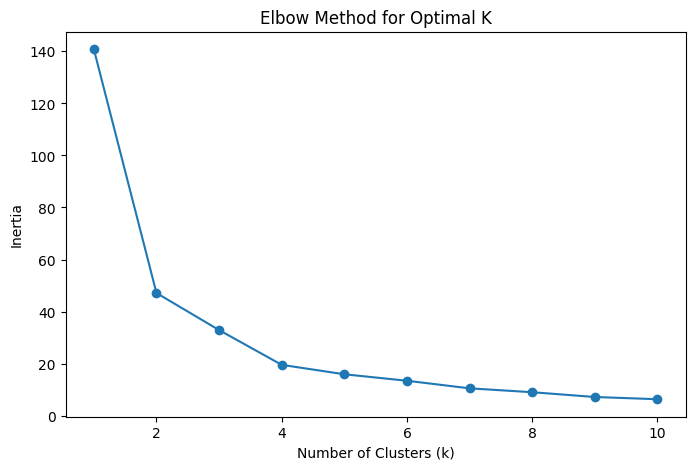

In [129]:
# Import KMeans and matplotlib
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Store inertia values
inertia = []

# Test different cluster numbers
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

**Bayesian Information Criterion (BIC) for GMM**

For GMM, we compare different numbers of clusters using BIC.

Lower BIC = better model fit.

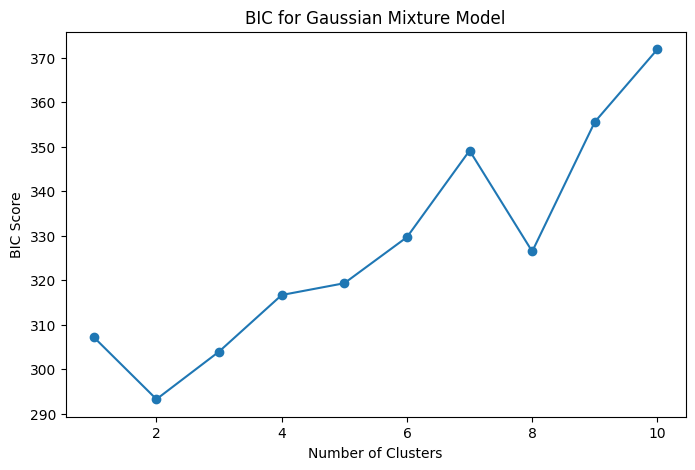

In [130]:
# Import Gaussian Mixture Model
from sklearn.mixture import GaussianMixture

# Store BIC values
bic_scores = []

# Test different cluster numbers
for k in K_range:
    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )

    gmm.fit(X_pca)
    bic_scores.append(gmm.bic(X_pca))

# Plot BIC scores
plt.figure(figsize=(8,5))
plt.plot(K_range, bic_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("BIC Score")
plt.title("BIC for Gaussian Mixture Model")
plt.show()

**Apply clustering models:**

*   K-Means for hard cluster assignments.
*   GMM for probabilistic clustering.

From the elbow method and BIC plots, choose the optimal number of clusters.

**Apply K-Means Clustering**

K-Means assigns each state to one specific cluster.

In [131]:
# Apply K-Means with optimal number of clusters

optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

# Fit model and get cluster labels
kmeans_labels = kmeans.fit_predict(X_pca)

# Add cluster labels
X_pca['KMeans_Cluster'] = kmeans_labels

# Display results
X_pca.head()


,PC1,PC2,KMeans_Cluster
0,1.210191,-0.842277,0
1,2.332187,1.539434,0
2,1.518593,0.503363,0
3,0.177776,-0.328029,2
4,2.066000,1.285497,0


**Apply Gaussian Mixture Model (GMM)**

GMM gives the probability of each data point belonging to each cluster.

In [132]:
# Apply GMM clustering

gmm = GaussianMixture(
    n_components=optimal_k,
    random_state=42
)

# Fit model and predict clusters
gmm_labels = gmm.fit_predict(
    X_pca[['PC1', 'PC2']]
)

# Add GMM cluster labels
X_pca['GMM_Cluster'] = gmm_labels

# Display results
X_pca.head()

,PC1,PC2,KMeans_Cluster,GMM_Cluster
0,1.210191,-0.842277,0,1
1,2.332187,1.539434,0,2
2,1.518593,0.503363,0,1
3,0.177776,-0.328029,2,0
4,2.066000,1.285497,0,2


**Optional: View cluster counts**

In [133]:
# Count observations in each cluster

print("K-Means cluster sizes:")
print(X_pca['KMeans_Cluster'].value_counts())

print("GMM cluster sizes:")
print(X_pca['GMM_Cluster'].value_counts())

K-Means cluster sizes:
KMeans_Cluster
0    19
2    17
1    14
Name: count, dtype: int64
GMM cluster sizes:
GMM_Cluster
0    31
1    15
2     4
Name: count, dtype: int64


### Visualization of Clustering Results

The clustering results are visualized using the two principal components generated from PCA (`PC1` and `PC2`). These components reduce the dataset into two dimensions, allowing the clusters to be displayed and compared visually.

- **K-Means Clustering:** Shows hard cluster assignments, where each state is assigned to a single cluster based on similarity in crime patterns.
- **Gaussian Mixture Model (GMM):** Shows probabilistic clustering, where each state is grouped based on the probability of belonging to different clusters.

**Visualize K-Means Clusters**

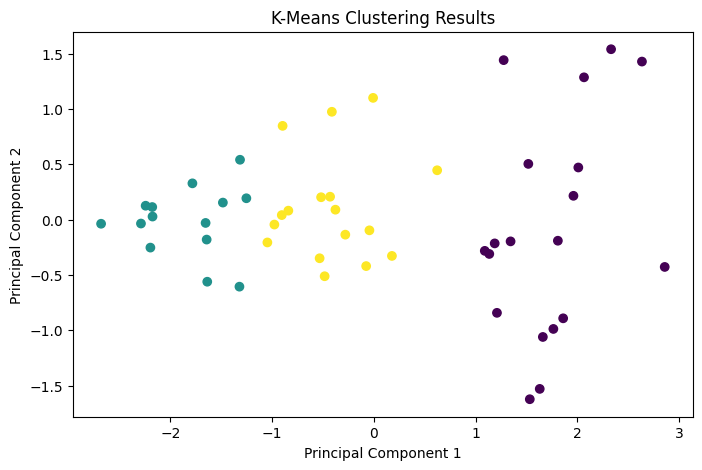

In [134]:
# Visualize K-Means clusters

plt.figure(figsize=(8,5))

plt.scatter(
    X_pca['PC1'],
    X_pca['PC2'],
    c=X_pca['KMeans_Cluster']
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering Results")
plt.show()

**Visualize GMM Clusters**

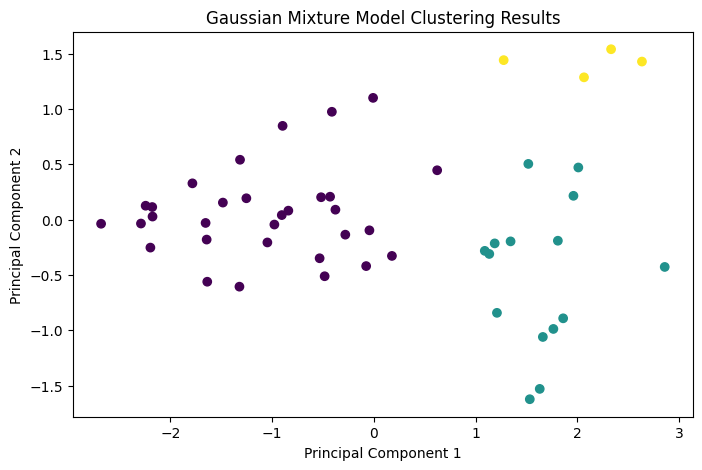

In [135]:
# Visualize GMM clusters

plt.figure(figsize=(8,5))

plt.scatter(
    X_pca['PC1'],
    X_pca['PC2'],
    c=X_pca['GMM_Cluster']
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Gaussian Mixture Model Clustering Results")
plt.show()

**Compare K-Means and GMM Side by Side**

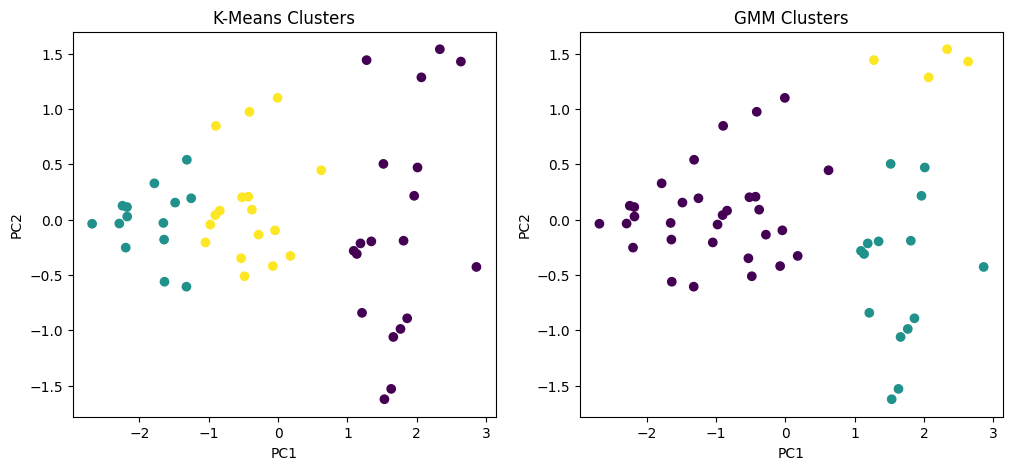

In [136]:
# Compare clustering methods

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# K-Means plot
axes[0].scatter(
    X_pca['PC1'],
    X_pca['PC2'],
    c=X_pca['KMeans_Cluster']
)

axes[0].set_title("K-Means Clusters")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")


# GMM plot
axes[1].scatter(
    X_pca['PC1'],
    X_pca['PC2'],
    c=X_pca['GMM_Cluster']
)

axes[1].set_title("GMM Clusters")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")


plt.show()

### Conclusion

In this analysis, the USArrests dataset was prepared for clustering by standardizing the features and selecting the most relevant crime-related variables. PCA was then applied to reduce the dimensionality of the data while preserving important patterns, allowing the clusters to be visualized using two principal components.

The optimal number of clusters was determined using the Elbow Method for K-Means and the Bayesian Information Criterion (BIC) for GMM. Both K-Means and Gaussian Mixture Models were applied to identify groups of states with similar crime characteristics.

K-Means provided clear cluster assignments by grouping states into distinct categories, while GMM provided a probabilistic approach by estimating the likelihood of each state belonging to different clusters. Comparing the two methods helps demonstrate how different clustering techniques can reveal patterns and similarities within crime data.